In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
X = np.random.rand(100, 1)
noise = np.random.normal(0, 0.1, (100, 1))
y = 2 * X + noise


split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]
print("Training Data")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nValidation Data")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Training Data
X_train shape: (80, 1)
y_train shape: (80, 1)

Validation Data
X_val shape: (20, 1)
y_val shape: (20, 1)


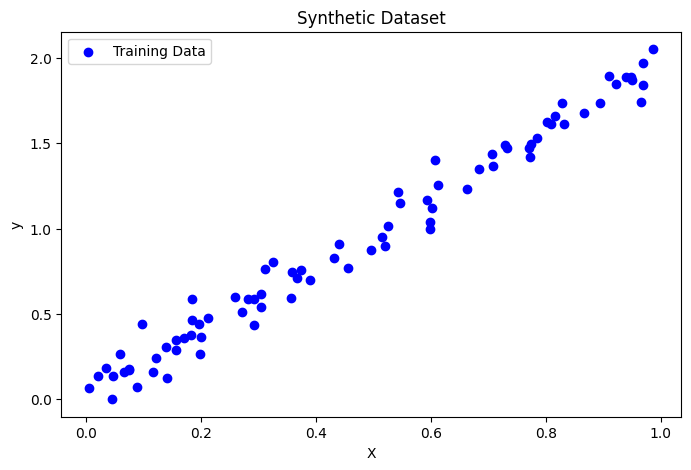

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue', label='Training Data')

plt.title("Synthetic Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()

2 Task 3

In [6]:
overfit_model = Sequential([
    Dense(32, input_shape=(1, ), activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='relu')
])
overfit_model.compile(optimizer='adam', metrics=['accuracy'], loss='mse')
history_overfit = overfit_model.fit(X_train, y_train, validation_data=[X_val, y_val], epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
dropout_model = Sequential([
    Dense(8, input_shape=(1, ), activation='relu'),
    Dropout(0.3),
    Dense(4, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='relu')
])

dropout_model.compile(optimizer='adam', loss='mse')
history_dropout = dropout_model.fit(X_train, y_train, validation_data=[X_val, y_val], epochs=100, verbose=0)

In [8]:
batchNorm_model = Sequential([
    Dense(8, input_shape=(1, ), activation='relu'),
    BatchNormalization(),
    Dense(4, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='relu')
])
batchNorm_model.compile(optimizer='adam', loss='mse')
history_batchmodel = batchNorm_model.fit(X_train, y_train, validation_data=[X_val, y_val], epochs=50, verbose=0)

TASK 4

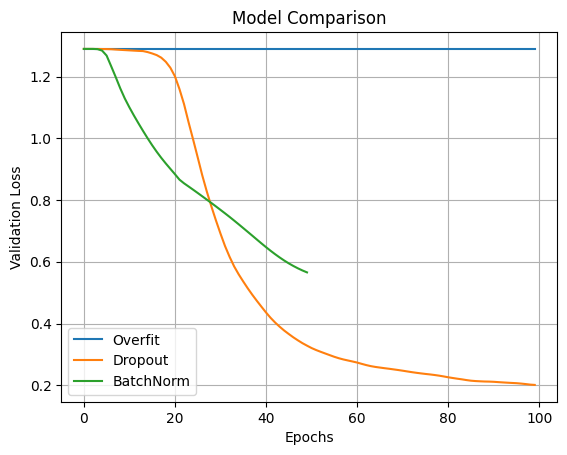

In [12]:

plt.plot(history_overfit.history['val_loss'], label='Overfit')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_batchmodel.history['val_loss'], label='BatchNorm')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

TASK 5 

In [13]:
SDG_model = Sequential([
    Dense(32, input_shape=(1, ), activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='relu')
])

SDG_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1), loss='mse')
sdg_model_history = SDG_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
Adam_model = Sequential([
    Dense(32, input_shape=(1, ), activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='relu')
])
Adam_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mse')
Adam_model_history = Adam_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


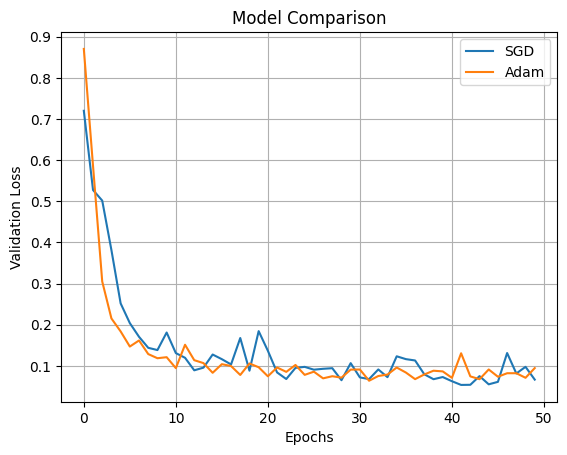

In [21]:

plt.plot(sdg_model_history.history['loss'], label='SGD')
plt.plot(Adam_model_history.history['loss'], label='Adam')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()